# Rule based control

The simplest thing you can put in front of a stormwater network is a rule: read
a depth, decide a valve position. This notebook builds one for scenario theta
and measures it against doing nothing.

Theta has two storage basins, each with an orifice you can set between fully
closed (`0.0`) and fully open (`1.0`). The objective penalizes flow at the
outlet above a threshold, and penalizes flooding heavily.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pystorms

plt.rcParams.update({"font.size": 14})
plt.style.use("seaborn-v0_8-whitegrid")

## Baseline: leave the valves alone

Calling `step()` with no argument leaves the network in its uncontrolled state.
That is the number any controller has to beat.

In [2]:
env = pystorms.scenarios.theta()

done = False
while not done:
    done = env.step()

uncontrolled_perf = env.performance()
uncontrolled_log = {
    "time": env.data_log["simulation_time"],
    "outflow": env.data_log["flow"]["8"],
}

print(f"uncontrolled performance: {uncontrolled_perf:.1f}")

uncontrolled performance: 1630.3


## The rule

Hold water back while a basin is filling, and only release once it is more than
half full. `state()` returns the depth in each basin, in the order the scenario
declares them.

In [3]:
def controller(depths, trigger=0.5, opening=0.5):
    """Open each orifice halfway once its basin passes the trigger depth."""
    actions = np.zeros(len(depths))
    actions[depths > trigger] = opening
    return actions

## Run it

In [4]:
env = pystorms.scenarios.theta()

depths = []
done = False
while not done:
    state = env.state()
    depths.append(state.copy())
    done = env.step(controller(state))

controlled_perf = env.performance()
depths = np.asarray(depths)

controlled_log = {
    "time": env.data_log["simulation_time"],
    "outflow": env.data_log["flow"]["8"],
}

print(f"uncontrolled performance: {uncontrolled_perf:.1f}")
print(f"rule based performance  : {controlled_perf:.1f}")
print(f"improvement             : {100 * (uncontrolled_perf - controlled_perf) / uncontrolled_perf:.1f}%")

uncontrolled performance: 1630.3
rule based performance  : 1125.8
improvement             : 30.9%


## What the rule did to the outlet

The threshold the objective cares about is drawn in red. The uncontrolled run
sends a sharp peak through it; the rule spreads the same volume out over a
longer window.

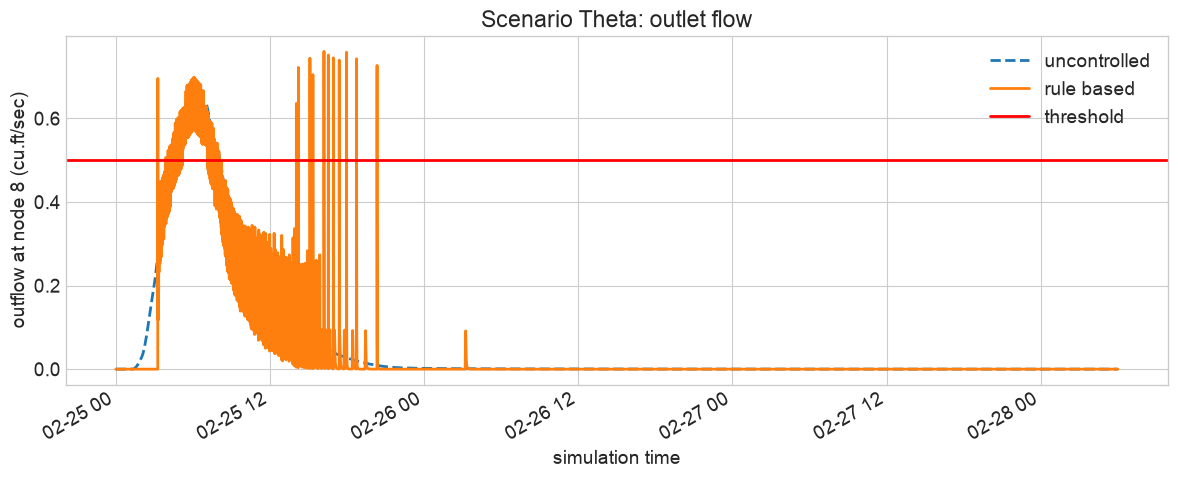

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(uncontrolled_log["time"], uncontrolled_log["outflow"],
        linestyle="--", linewidth=2.0, label="uncontrolled")
ax.plot(controlled_log["time"], controlled_log["outflow"],
        linewidth=2.0, label="rule based")
ax.axhline(env.threshold, color="red", linewidth=2.0, label="threshold")
ax.set_xlabel("simulation time")
ax.set_ylabel("outflow at node 8 (cu.ft/sec)")
ax.set_title("Scenario Theta: outlet flow")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()

## And to the basins

Each basin fills until it crosses the trigger, then drains at the fixed
opening.

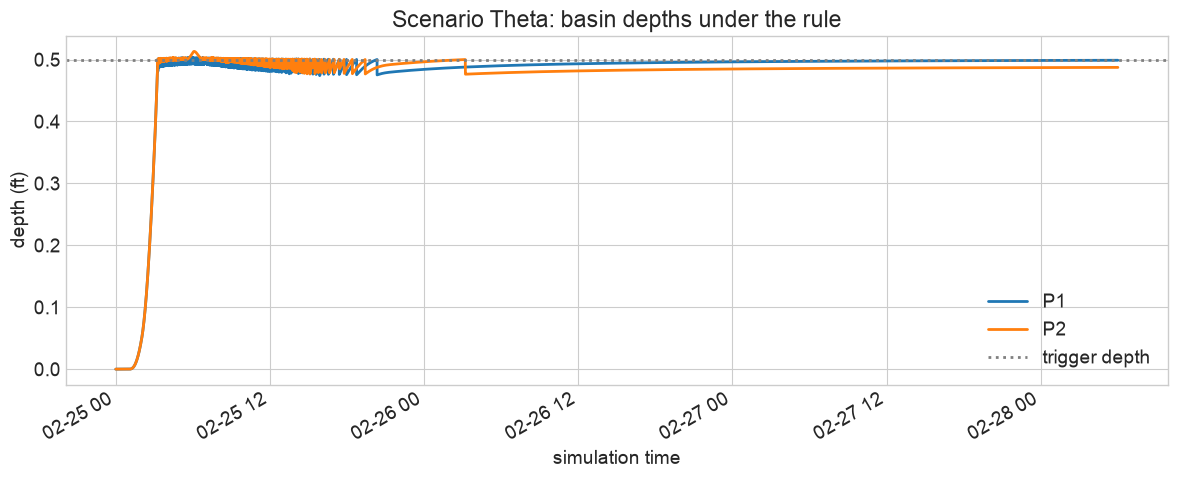

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
for i, name in enumerate(["P1", "P2"]):
    ax.plot(controlled_log["time"], depths[:, i], linewidth=2.0, label=name)
ax.axhline(0.5, color="grey", linestyle=":", linewidth=2.0, label="trigger depth")
ax.set_xlabel("simulation time")
ax.set_ylabel("depth (ft)")
ax.set_title("Scenario Theta: basin depths under the rule")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()

## Sweeping the rule's parameters

Two numbers decide everything here, and theta runs in a fraction of a second,
so we can simply try a grid of them.

In [7]:
records = []
for trigger in [0.25, 0.5, 0.75, 1.0]:
    for opening in [0.25, 0.5, 0.75, 1.0]:
        env = pystorms.scenarios.theta()
        done = False
        while not done:
            done = env.step(controller(env.state(), trigger, opening))
        records.append({"trigger": trigger, "opening": opening,
                        "performance": env.performance()})

sweep = pd.DataFrame(records).pivot(index="trigger", columns="opening",
                                    values="performance")
sweep.round(1)

opening,0.25,0.50,0.75,1.00
trigger,,,,
0.25,1413.6,1342.3,1308.2,1288.0
0.50,1342.1,1125.8,1036.7,1391.5
0.75,1268.5,990.8,8172.9,8581.3
1.00,1176.9,952.4,8600.0,8024.1


In [8]:
best = pd.DataFrame(records).sort_values("performance").iloc[0]
print(f"best trigger    : {best['trigger']}")
print(f"best opening    : {best['opening']}")
print(f"performance     : {best['performance']:.1f}")
print(f"vs uncontrolled : {100 * (uncontrolled_perf - best['performance']) / uncontrolled_perf:.1f}% better")

best trigger    : 1.0
best opening    : 0.5
performance     : 952.4
vs uncontrolled : 41.6% better


Note that being able to build a scenario repeatedly inside one Python
process, as the sweep above does, requires pystorms 2.0 or newer.

## Exercises

1. The rule ignores how full the *other* basin is. Write a controller that
   compares the two filling degrees and releases from the fuller one first.
   `tutorials/scenario_theta.py` has an equal filling implementation to compare
   against.
2. Re-run the sweep against `pystorms.scenarios.theta(level="2")`, where the
   depth readings carry noise and the valves occasionally stick. How much of
   the improvement survives?